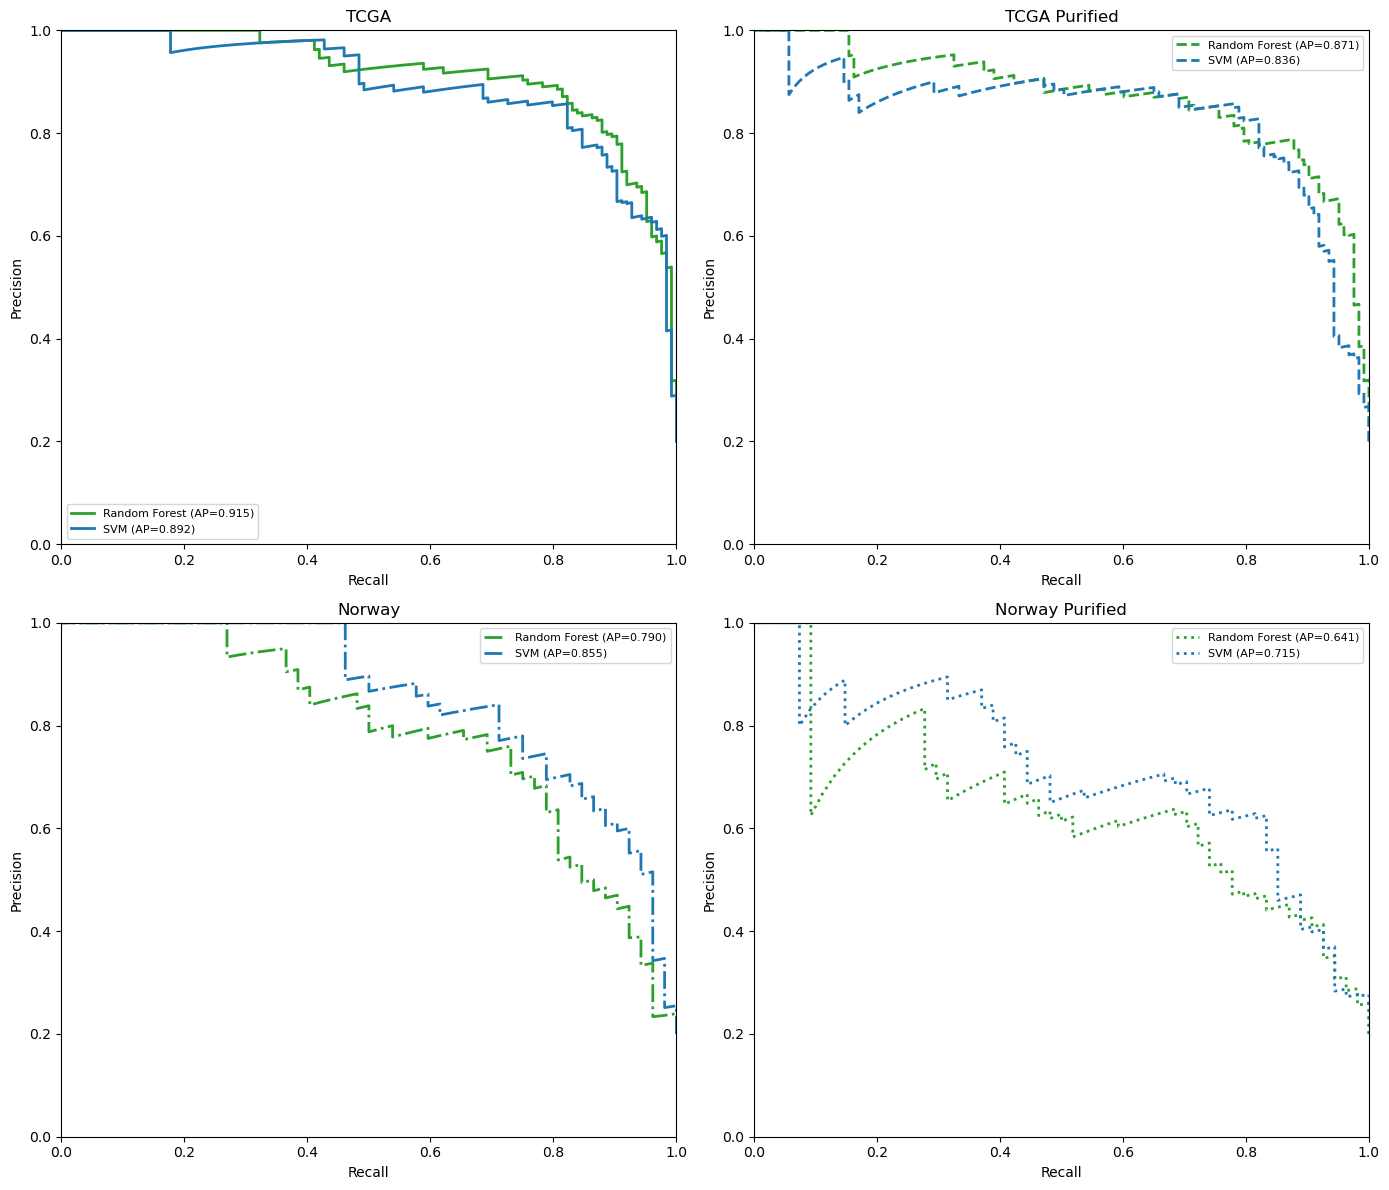

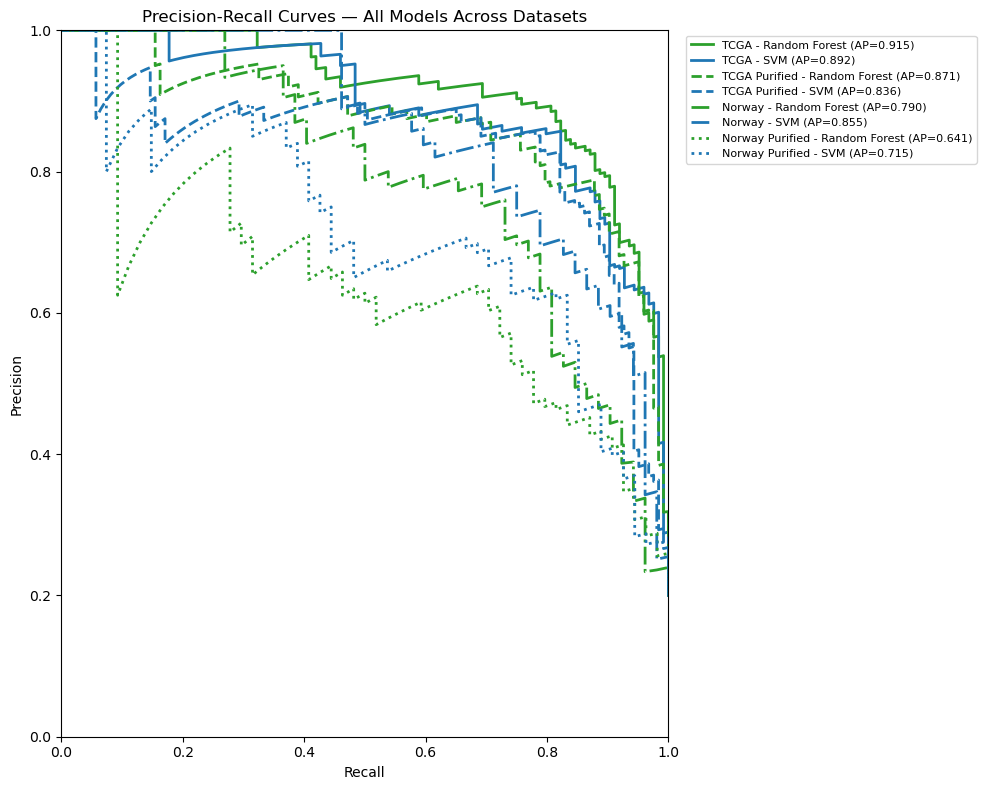

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, roc_auc_score, f1_score
from sklearn.preprocessing import label_binarize
import itertools
from sklearn.metrics import precision_recall_curve, average_precision_score

# Load predictions
RF_TCGA_preds = np.load("RF_TCGA_preds.npy")
SVM_TCGA_preds = np.load("SVM_TCGA_preds.npy")
#NN_TCGA_preds = np.load("NN_TCGA_preds.npy")

RF_TCGA_IP_preds = np.load("RF_TCGA_IP_preds.npy")
SVM_TCGA_IP_preds = np.load("SVM_TCGA_IP_preds.npy")
#NN_TCGA_IP_preds = np.load("NN_TCGA_IP_preds.npy")

RF_Norway_preds = np.load("RF_Norway_preds.npy")
SVM_Norway_preds = np.load("SVM_Norway_preds.npy")
#NN_Norway_preds = np.load("NN_Norway_preds.npy")

RF_Norway_IP_preds = np.load("RF_Norway_IP_preds.npy")
SVM_Norway_IP_preds = np.load("SVM_Norway_IP_preds.npy")
#NN_Norway_IP_preds = np.load("NN_Norway_IP_preds.npy")

# Load y_test for each dataset
y_test_TCGA = pd.read_csv("../Datasets/TCGA Dataset Splits/Y_test.csv").values.ravel()
y_test_TCGA_purified = pd.read_csv("../Datasets/TCGA InfiniumPurify Dataset Splits/Y_test.csv").values.ravel()
y_test_Norway = pd.read_csv("../Datasets/Norway Dataset Splits/Y_test.csv").values.ravel()
y_test_Norway_purified = pd.read_csv("../Datasets/Norway InfiniumPurify Dataset Splits/Y_test.csv").values.ravel()

model_colors = {
    "Random Forest": "tab:green",
    "SVM": "tab:blue",
    "Neural Network": "tab:red"
}

dataset_styles = {
    "TCGA": "-",
    "TCGA Purified": "--",
    "Norway": "-.",
    "Norway Purified": ":"
}

datasets = [
    ("TCGA", y_test_TCGA, [
        ("Random Forest", RF_TCGA_preds),
        ("SVM", SVM_TCGA_preds),
        #("Neural Network", NN_TCGA_preds)
    ]),

    ("TCGA Purified", y_test_TCGA_purified, [
        ("Random Forest", RF_TCGA_IP_preds),
        ("SVM", SVM_TCGA_IP_preds),
        #("Neural Network", NN_TCGA_IP_preds)
    ]),

    ("Norway", y_test_Norway, [
        ("Random Forest", RF_Norway_preds),
        ("SVM", SVM_Norway_preds),
        #("Neural Network", NN_Norway_preds)
    ]),

    ("Norway Purified", y_test_Norway_purified, [
        ("Random Forest", RF_Norway_IP_preds),
        ("SVM", SVM_Norway_IP_preds),
        #("Neural Network", NN_Norway_IP_preds)
    ]),
]

fig, axes = plt.subplots(2,2, figsize=(14,12))
axes = axes.ravel()

for idx, (dataset_name, y_true, models) in enumerate(datasets):

    ax = axes[idx]

    classes = np.unique(y_true)
    y_bin = label_binarize(y_true, classes=classes)

    for model_name, preds in models:

        if preds.ndim == 1:
            preds = preds.reshape(-1,1)

        precision, recall, _ = precision_recall_curve(y_bin.ravel(), preds.ravel())
        ap = average_precision_score(y_bin, preds, average="micro")

        ax.plot(
            recall,
            precision,
            color=model_colors[model_name],
            linestyle=dataset_styles[dataset_name],
            linewidth=2,
            label=f"{model_name} (AP={ap:.3f})"
        )

    ax.set_title(dataset_name)
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_xlim(0,1)
    ax.set_ylim(0,1)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


# -------------------------
# FINAL COMPARISON GRAPH
# -------------------------
plt.figure(figsize=(10,8))

for dataset_name, y_true, models in datasets:

    classes = np.unique(y_true)
    y_bin = label_binarize(y_true, classes=classes)

    for model_name, preds in models:

        if preds.ndim == 1:
            preds = preds.reshape(-1,1)

        precision, recall, _ = precision_recall_curve(y_bin.ravel(), preds.ravel())
        ap = average_precision_score(y_bin, preds, average="micro")

        plt.plot(
            recall,
            precision,
            color=model_colors[model_name],
            linestyle=dataset_styles[dataset_name],
            linewidth=2,
            label=f"{dataset_name} - {model_name} (AP={ap:.3f})"
        )

plt.title("Precision-Recall Curves — All Models Across Datasets")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.xlim(0,1)
plt.ylim(0,1)

plt.legend(bbox_to_anchor=(1.02,1), loc="upper left", fontsize=8)

plt.tight_layout()
plt.show()